# 특성 공학(Feature Engineering) 파이프라인 과제
## Titanic Dataset — 생존 여부 예측 (Classification)


## 0. 라이브러리 설치

In [26]:
!pip install xgboost lightgbm shap -q

---
## STEP 01. 데이터 준비



In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


SEED = 42


df = pd.read_csv(
    "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
)

print("Shape:", df.shape)
df.head()


Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [28]:
# 컬럼 설명표
column_info = pd.DataFrame({
    "Column": [
        "PassengerId", "Survived", "Pclass", "Name",
        "Sex", "Age", "SibSp", "Parch",
        "Ticket", "Fare", "Cabin", "Embarked"
    ],
    "Type": [
        "int", "int(Target)", "int", "object",
        "object", "float", "int", "int",
        "object", "float", "object", "object"
    ],
    "Description": [
        "승객 ID",
        "생존 여부 (0=사망, 1=생존)",
        "객실 등급 (1=1등석, 2=2등석, 3=3등석)",
        "승객 이름",
        "성별 (male/female)",
        "나이",
        "함께 탑승한 형제/배우자 수",
        "함께 탑승한 부모/자녀 수",
        "티켓 번호",
        "운임 요금",
        "객실 번호",
        "탑승 항구 (C=Cherbourg, Q=Queenstown, S=Southampton)"
    ]
})
column_info


,Column,Type,Description
0,PassengerId,int,승객 ID
1,Survived,int(Target),"생존 여부 (0=사망, 1=생존)"
2,Pclass,int,"객실 등급 (1=1등석, 2=2등석, 3=3등석)"
3,Name,object,승객 이름
4,Sex,object,성별 (male/female)
5,Age,float,나이
6,SibSp,int,함께 탑승한 형제/배우자 수
7,Parch,int,함께 탑승한 부모/자녀 수
8,Ticket,object,티켓 번호
9,Fare,float,운임 요금


---
## STEP 02. 탐색적 데이터 분석 (EDA)


### 2-1. 결측치 분석

In [29]:
# 결측치 비율 분석
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Ratio (%)": round(df.isnull().mean() * 100, 2)
})
missing.sort_values(by="Missing Ratio (%)", ascending=False)


,Missing Count,Missing Ratio (%)
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


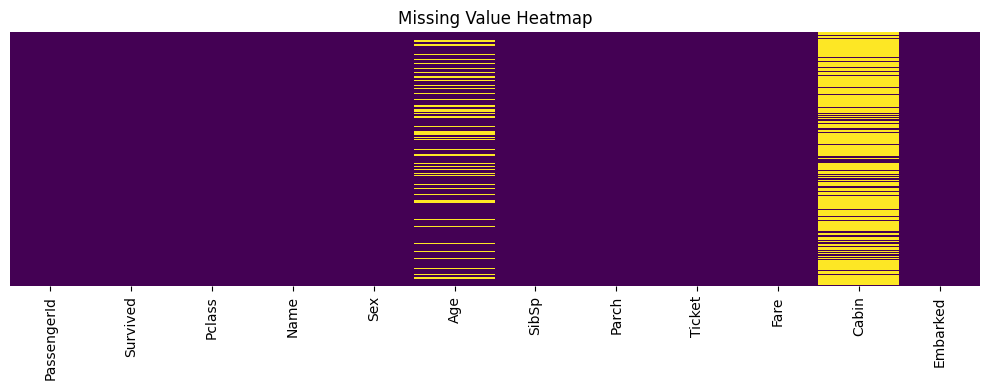

In [30]:
# Missing Value Heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.tight_layout()
plt.show()


### 2-2. 타겟 변수 분포

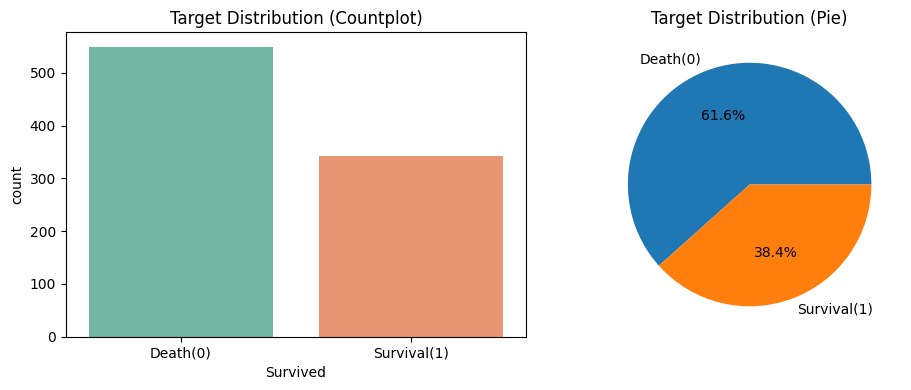

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x="Survived", data=df, palette="Set2", ax=axes[0])
axes[0].set_title("Target Distribution (Countplot)")
axes[0].set_xticklabels(["Death(0)", "Survival(1)"])

survived_counts = df["Survived"].value_counts()
axes[1].pie(
    survived_counts,
    labels=["Death(0)", "Survival(1)"],
    autopct="%1.1f%%",

)
axes[1].set_title("Target Distribution (Pie)")

plt.tight_layout()
plt.show()


### 2-3. 수치형 변수 분포 (Histogram)

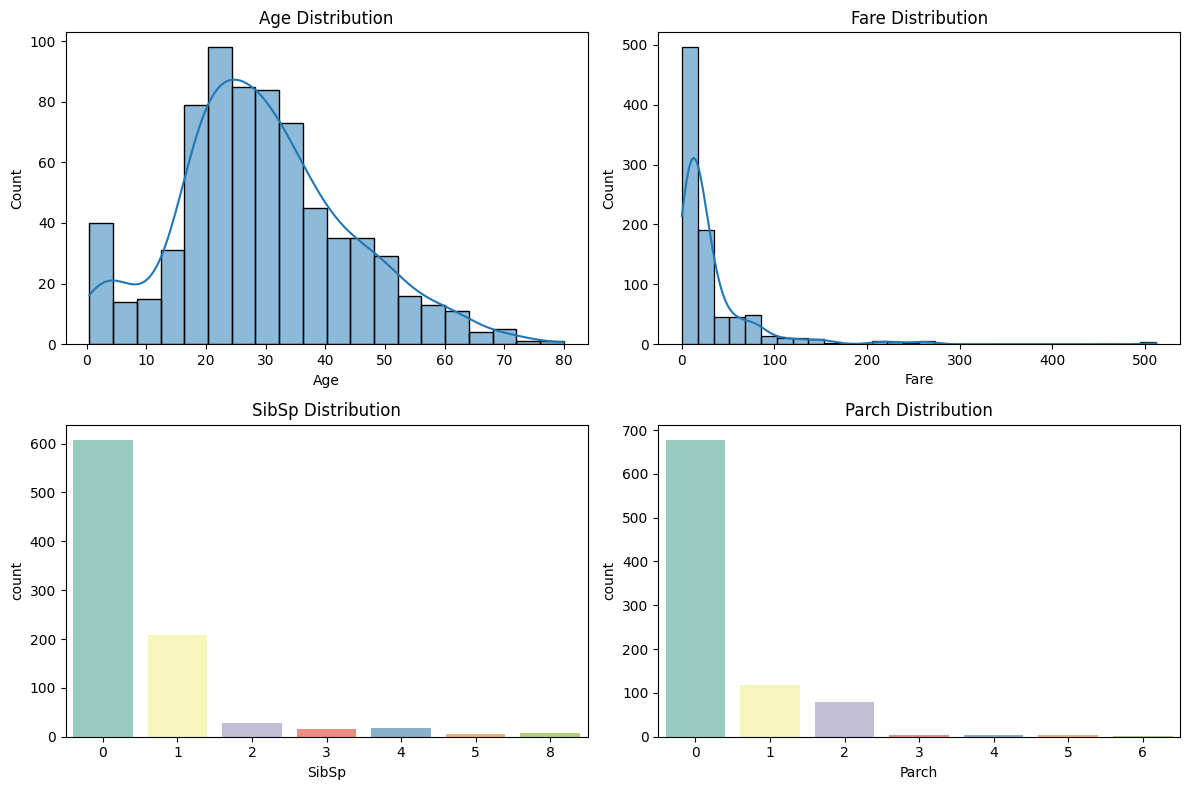

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["Age"], bins=20, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution")

sns.histplot(df["Fare"], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Fare Distribution")

sns.countplot(x="SibSp", data=df, ax=axes[1, 0], palette="Set3")
axes[1, 0].set_title("SibSp Distribution")

sns.countplot(x="Parch", data=df, ax=axes[1, 1], palette="Set3")
axes[1, 1].set_title("Parch Distribution")

plt.tight_layout()
plt.show()


### 2-4. 이상치 탐색 (Boxplot)

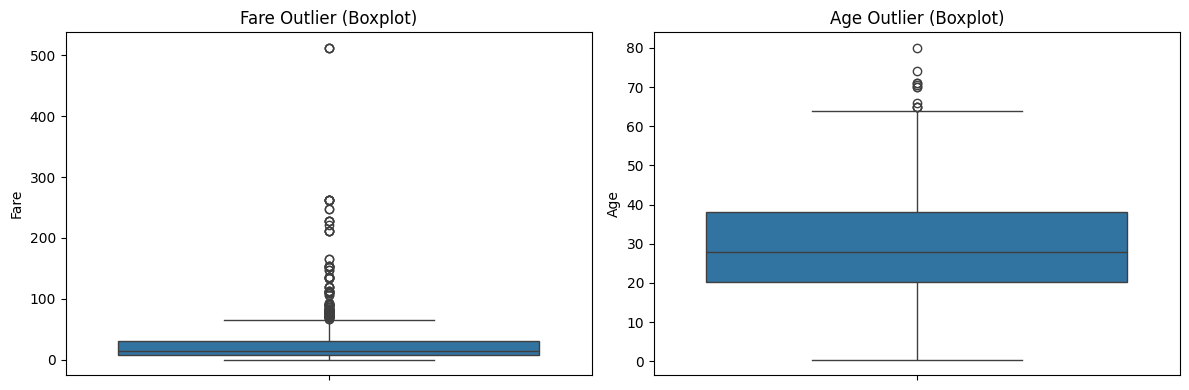

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=df["Fare"], ax=axes[0])
axes[0].set_title("Fare Outlier (Boxplot)")

sns.boxplot(y=df["Age"], ax=axes[1])
axes[1].set_title("Age Outlier (Boxplot)")

plt.tight_layout()
plt.show()

### 2-5. 범주형 변수 분석 (Barplot / Countplot)

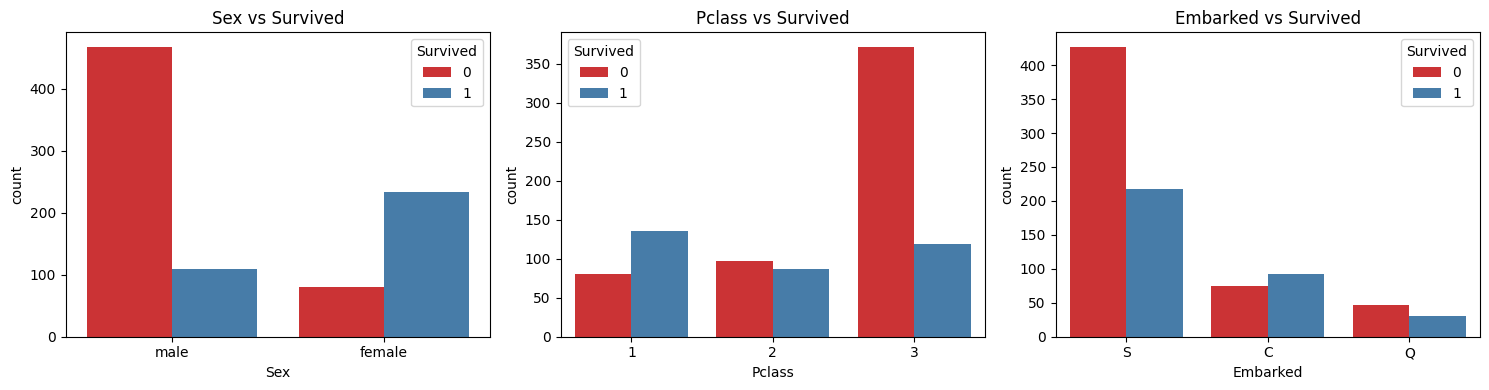

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(x="Sex", data=df, hue="Survived", palette="Set1", ax=axes[0])
axes[0].set_title("Sex vs Survived")

sns.countplot(x="Pclass", data=df, hue="Survived", palette="Set1", ax=axes[1])
axes[1].set_title("Pclass vs Survived")

sns.countplot(x="Embarked", data=df, hue="Survived", palette="Set1", ax=axes[2])
axes[2].set_title("Embarked vs Survived")

plt.tight_layout()
plt.show()


### 2-6. 상관관계 분석 (Heatmap)

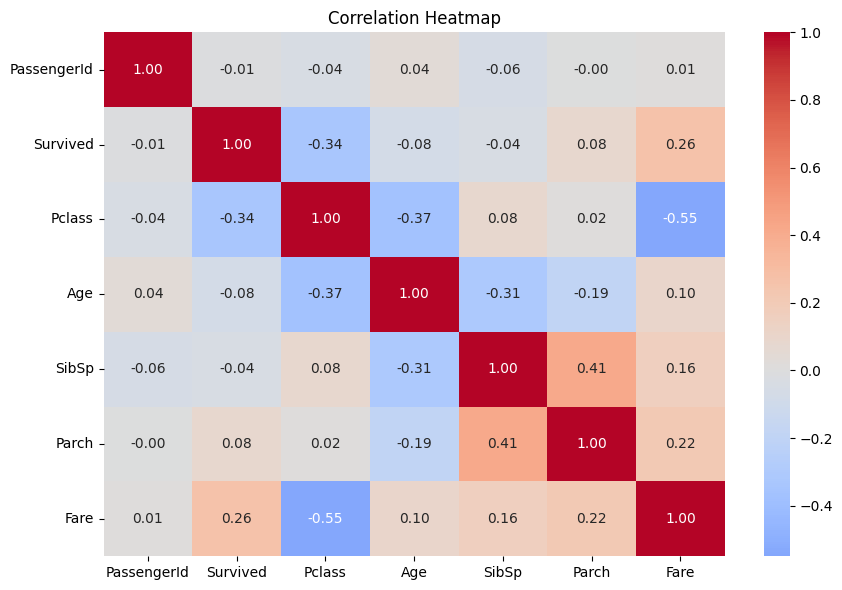

In [35]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(9, 6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


---
## STEP 03. 특성 공학(Feature Engineering) 파이프라인

### 3-4. 파생 변수 생성 (공통 전처리 — 실험 전 적용)
먼저 모든 실험에 공통으로 사용할 파생 변수를 생성하고, 불필요한 컬럼을 제거합니다.


In [36]:
# 원본 데이터 보존
raw_df = pd.read_csv(
    "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
)

# ── 파생 변수 생성 (최소 2개) ──
# 1. AgeGroup: 나이 구간화
raw_df["AgeGroup"] = pd.cut(
    raw_df["Age"].fillna(raw_df["Age"].median()),
    bins=[0, 18, 35, 60, 100],
    labels=["Child", "Young", "Adult", "Senior"]
)

# 2. FamilySize: 가족 규모
raw_df["FamilySize"] = raw_df["SibSp"] + raw_df["Parch"] + 1

# 3. FarePerPerson: 1인당 운임
raw_df["FarePerPerson"] = raw_df["Fare"] / raw_df["FamilySize"]

# 불필요한 컬럼 제거
raw_df = raw_df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

### 3-1 ~ 3-3. 결측치 처리 / 인코딩 / 스케일링 비교 실험 함수

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

def run_experiment(
    df,
    impute_strategy="median",   # mean | median | most_frequent
    encoding="onehot",          # onehot | label
    scaler_type="standard",     # standard | minmax | robust | none
    feature_selection=False,
    n_features=8,
    model_type="rf"             # rf | logistic | xgb | lgbm
):
    """
    결측치 처리 / 인코딩 / 스케일링 / Feature Selection 조합 실험 함수
    """
    from xgboost import XGBClassifier
    import lightgbm as lgb

    data = df.copy()

    # ── 결측치 처리 ──────────────────────────────
    if impute_strategy == "most_frequent":
        data["Age"] = data["Age"].fillna(data["Age"].mode()[0])
    else:
        fill_val = data["Age"].mean() if impute_strategy == "mean" else data["Age"].median()
        data["Age"] = data["Age"].fillna(fill_val)

    data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])
    data["FarePerPerson"] = data["FarePerPerson"].fillna(data["FarePerPerson"].median())

    # ── 인코딩 ──────────────────────────────────
    cat_cols = ["Sex", "Embarked", "AgeGroup"]
    if encoding == "onehot":
        data = pd.get_dummies(data, columns=cat_cols, drop_first=True)
    else:
        le = LabelEncoder()
        for col in cat_cols:
            data[col] = le.fit_transform(data[col].astype(str))

    # ── X / y 분리 ───────────────────────────────
    X = data.drop("Survived", axis=1)
    y = data["Survived"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )

    # ── 스케일링 ────────────────────────────────
    if scaler_type != "none":
        scaler_map = {
            "standard": StandardScaler(),
            "minmax":   MinMaxScaler(),
            "robust":   RobustScaler()
        }
        scaler = scaler_map[scaler_type]
        num_cols = X_train.select_dtypes(include=np.number).columns
        X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
        X_test[num_cols]  = scaler.transform(X_test[num_cols])

    # ── Feature Selection ───────────────────────
    selected_features = None
    if feature_selection:
        rf_fs = RandomForestClassifier(n_estimators=200, random_state=SEED)
        rf_fs.fit(X_train, y_train)
        importances = pd.Series(rf_fs.feature_importances_, index=X_train.columns)
        top_features = importances.nlargest(n_features).index.tolist()
        selected_features = top_features
        X_train = X_train[top_features]
        X_test  = X_test[top_features]

    # ── 모델 학습 ────────────────────────────────
    model_map = {
        "rf":      RandomForestClassifier(n_estimators=300, random_state=SEED),
        "logistic": LogisticRegression(max_iter=1000, random_state=SEED),
        "xgb":     XGBClassifier(random_state=SEED, eval_metric="logloss", verbosity=0),
        "lgbm":    lgb.LGBMClassifier(random_state=SEED, verbose=-1)
    }
    model = model_map[model_type]
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy":  round(accuracy_score(y_test, pred), 4),
        "Precision": round(precision_score(y_test, pred), 4),
        "Recall":    round(recall_score(y_test, pred), 4),
        "F1":        round(f1_score(y_test, pred), 4),
        "ROC_AUC":   round(roc_auc_score(y_test, prob), 4),
        "Selected_Features": selected_features
    }

print("run_experiment 함수 정의 완료")


run_experiment 함수 정의 완료


### 3-1. 결측치 처리 비교

In [38]:
imputation_results = []

for imp in ["mean", "median", "most_frequent"]:
    result = run_experiment(
        raw_df,
        impute_strategy=imp,
        encoding="onehot",
        scaler_type="standard",
        feature_selection=False,
        model_type="rf"
    )
    result["Imputation"] = imp
    imputation_results.append(result)

imp_df = pd.DataFrame(imputation_results)[
    ["Imputation", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
]
print("=== 결측치 처리 방법별 성능 비교 ===")
display(imp_df)


=== 결측치 처리 방법별 성능 비교 ===


,Imputation,Accuracy,Precision,Recall,F1,ROC_AUC
0,mean,0.7989,0.7463,0.7246,0.7353,0.8231
1,median,0.8101,0.7692,0.7246,0.7463,0.8260
2,most_frequent,0.8101,0.7536,0.7536,0.7536,0.8200


### 3-2. 범주형 인코딩 비교

In [39]:
encoding_results = []

for enc in ["label", "onehot"]:
    result = run_experiment(
        raw_df,
        impute_strategy="median",
        encoding=enc,
        scaler_type="standard",
        feature_selection=False,
        model_type="rf"
    )
    result["Encoding"] = enc
    encoding_results.append(result)

enc_df = pd.DataFrame(encoding_results)[
    ["Encoding", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
]
print("=== 인코딩 방법별 성능 비교 ===")
display(enc_df)


=== 인코딩 방법별 성능 비교 ===


,Encoding,Accuracy,Precision,Recall,F1,ROC_AUC
0,label,0.8101,0.7692,0.7246,0.7463,0.8209
1,onehot,0.8101,0.7692,0.7246,0.7463,0.8260


### 3-3. 스케일링 비교

In [40]:
scaling_results = []

for scale in ["standard", "minmax", "robust"]:
    result = run_experiment(
        raw_df,
        impute_strategy="median",
        encoding="onehot",
        scaler_type=scale,
        feature_selection=False,
        model_type="rf"
    )
    result["Scaler"] = scale
    scaling_results.append(result)

scale_df = pd.DataFrame(scaling_results)[
    ["Scaler", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
]
print("=== 스케일링 방법별 성능 비교 ===")
display(scale_df)


=== 스케일링 방법별 성능 비교 ===


,Scaler,Accuracy,Precision,Recall,F1,ROC_AUC
0,standard,0.8101,0.7692,0.7246,0.7463,0.8260
1,minmax,0.8156,0.7727,0.7391,0.7556,0.8271
2,robust,0.8101,0.7692,0.7246,0.7463,0.8260


---
## STEP 04. 변수 선택 (Feature Selection)
### 4-1. Random Forest Feature Importance


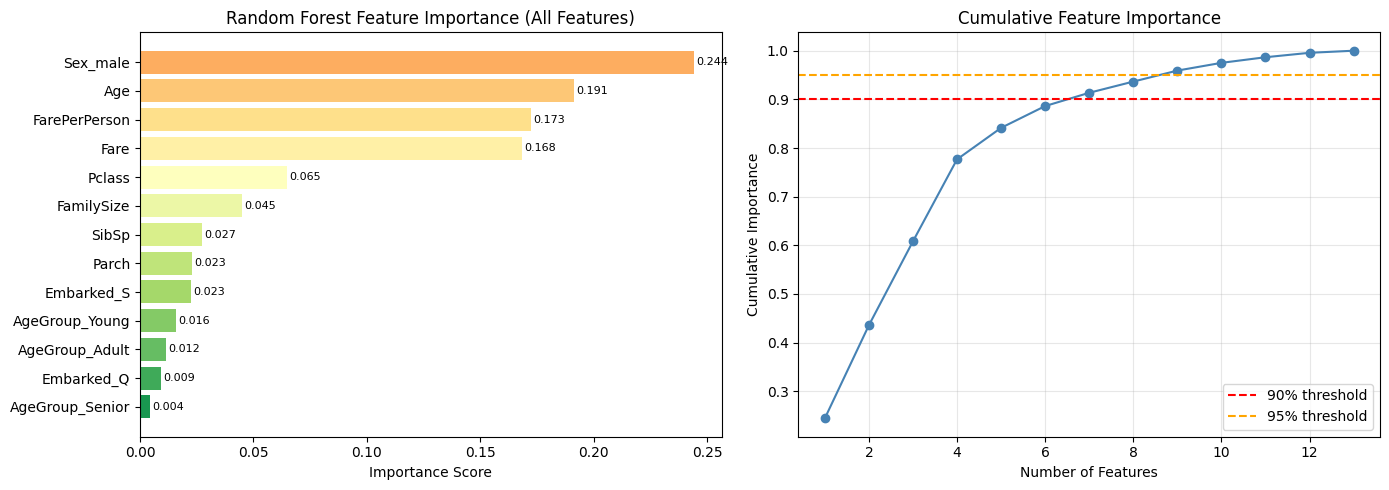

Feature Importance Top 10:


,Feature,Importance
0,Sex_male,0.244281
1,Age,0.191387
2,FarePerPerson,0.172514
3,Fare,0.168460
4,Pclass,0.064770
5,FamilySize,0.044798
6,SibSp,0.027304
7,Parch,0.023003
8,Embarked_S,0.022613
9,AgeGroup_Young,0.015905


In [41]:
from sklearn.preprocessing import LabelEncoder

def prepare_data_for_importance(df):
    data = df.copy()
    data["Age"] = data["Age"].fillna(data["Age"].median())
    data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])
    data["FarePerPerson"] = data["FarePerPerson"].fillna(data["FarePerPerson"].median())
    data = pd.get_dummies(data, columns=["Sex", "Embarked", "AgeGroup"], drop_first=True)
    X = data.drop("Survived", axis=1)
    y = data["Survived"]
    return X, y

X_all, y_all = prepare_data_for_importance(raw_df)
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all)

scaler = StandardScaler()
num_cols = X_tr.select_dtypes(include=np.number).columns
X_tr[num_cols] = scaler.fit_transform(X_tr[num_cols])
X_te[num_cols] = scaler.transform(X_te[num_cols])

rf_fi = RandomForestClassifier(n_estimators=300, random_state=SEED)
rf_fi.fit(X_tr, y_tr)

importance = pd.DataFrame({
    "Feature": X_all.columns,
    "Importance": rf_fi.feature_importances_
}).sort_values("Importance", ascending=False)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(importance)))
axes[0].barh(importance["Feature"][::-1], importance["Importance"][::-1], color=colors[::-1])
axes[0].set_title("Random Forest Feature Importance (All Features)", fontsize=12)
axes[0].set_xlabel("Importance Score")
for i, (feat, imp) in enumerate(zip(importance["Feature"][::-1], importance["Importance"][::-1])):
    axes[0].text(imp + 0.001, i, f"{imp:.3f}", va='center', fontsize=8)

# Cumulative importance
cumulative = importance["Importance"].cumsum()
axes[1].plot(range(1, len(cumulative)+1), cumulative, marker='o', color='steelblue')
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95% threshold')
axes[1].set_title("Cumulative Feature Importance", fontsize=12)
axes[1].set_xlabel("Number of Features")
axes[1].set_ylabel("Cumulative Importance")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Feature Importance Top 10:")
display(importance.head(10).reset_index(drop=True))


### 4-2. SelectKBest (f_classif)

In [42]:
selector = SelectKBest(score_func=f_classif, k=8)
X_train_fs = selector.fit_transform(X_tr, y_tr)
X_test_fs  = selector.transform(X_te)

selected_features = X_all.columns[selector.get_support()].tolist()
scores = selector.scores_[selector.get_support()]

kbest_df = pd.DataFrame({
    "Feature": selected_features,
    "F-Score": scores.round(2)
}).sort_values("F-Score", ascending=False)

print("=== SelectKBest Top 8 Features ===")
display(kbest_df.reset_index(drop=True))


=== SelectKBest Top 8 Features ===


,Feature,F-Score
0,Sex_male,306.59
1,Pclass,97.84
2,Fare,58.31
3,FarePerPerson,36.80
4,Embarked_S,23.55
5,AgeGroup_Young,5.14
6,Parch,5.07
7,Age,3.63


### 4-3. Feature Selection 전/후 성능 비교

In [43]:
comparison_fs = []

for fs, label in [(False, "All Features"), (True, "Top 8 (RF Importance)")]:
    result = run_experiment(
        raw_df,
        impute_strategy="median",
        encoding="onehot",
        scaler_type="standard",
        feature_selection=fs,
        n_features=8,
        model_type="rf"
    )
    result["Experiment"] = label
    result["Feature Selection"] = "O" if fs else "X"
    comparison_fs.append(result)

fs_df = pd.DataFrame(comparison_fs)[
    ["Experiment", "Feature Selection", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
]
print("=== Feature Selection 전/후 성능 비교 ===")
display(fs_df)


=== Feature Selection 전/후 성능 비교 ===


,Experiment,Feature Selection,Accuracy,Precision,Recall,F1,ROC_AUC
0,All Features,X,0.8101,0.7692,0.7246,0.7463,0.8260
1,Top 8 (RF Importance),O,0.7933,0.7353,0.7246,0.7299,0.8292


---
## STEP 05. 모델 학습 및 평가
### 5-1. 개별 모델 학습 (Best 설정 기반)


In [44]:
from sklearn.metrics import classification_report, roc_curve, auc

# Best 전처리: median imputation + onehot + standard scaling
def get_best_data(df, feature_selection=True, n_features=8):
    data = df.copy()
    data["Age"] = data["Age"].fillna(data["Age"].median())
    data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])
    data["FarePerPerson"] = data["FarePerPerson"].fillna(data["FarePerPerson"].median())
    data = pd.get_dummies(data, columns=["Sex", "Embarked", "AgeGroup"], drop_first=True)

    X = data.drop("Survived", axis=1)
    y = data["Survived"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )

    scaler = StandardScaler()
    num_cols = X_train.select_dtypes(include=np.number).columns
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols]  = scaler.transform(X_test[num_cols])

    if feature_selection:
        rf_fs = RandomForestClassifier(n_estimators=200, random_state=SEED)
        rf_fs.fit(X_train, y_train)
        top_features = pd.Series(rf_fs.feature_importances_, index=X_train.columns)                         .nlargest(n_features).index.tolist()
        X_train = X_train[top_features]
        X_test  = X_test[top_features]

    return X_train, X_test, y_train, y_test

X_train_b, X_test_b, y_train_b, y_test_b = get_best_data(raw_df)


In [45]:
from xgboost import XGBClassifier
import lightgbm as lgb

models_dict = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Random Forest":       RandomForestClassifier(n_estimators=300, random_state=SEED),
    "XGBoost":             XGBClassifier(random_state=SEED, eval_metric="logloss", verbosity=0),
    "LightGBM":            lgb.LGBMClassifier(random_state=SEED, verbose=-1)
}

eval_results = []
trained_models = {}

for name, model in models_dict.items():
    model.fit(X_train_b, y_train_b)
    pred = model.predict(X_test_b)
    prob = model.predict_proba(X_test_b)[:, 1]
    trained_models[name] = (model, prob)

    eval_results.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test_b, pred), 4),
        "Precision": round(precision_score(y_test_b, pred), 4),
        "Recall":    round(recall_score(y_test_b, pred), 4),
        "F1":        round(f1_score(y_test_b, pred), 4),
        "ROC_AUC":   round(roc_auc_score(y_test_b, prob), 4)
    })
    print(f"\n=== {name} ===")
    print(classification_report(y_test_b, pred))

eval_df = pd.DataFrame(eval_results).sort_values("ROC_AUC", ascending=False)
print("\n=== 모델 성능 요약 ===")
display(eval_df.reset_index(drop=True))



=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.84      0.83       110
           1       0.74      0.72      0.73        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179


=== XGBoost ===
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weigh

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.7989,0.7797,0.6667,0.7188,0.8497
1,Random Forest,0.7933,0.7353,0.7246,0.7299,0.8292
2,LightGBM,0.7933,0.7500,0.6957,0.7218,0.8235
3,XGBoost,0.8156,0.7812,0.7246,0.7519,0.8063


### 5-2. ROC Curve 비교

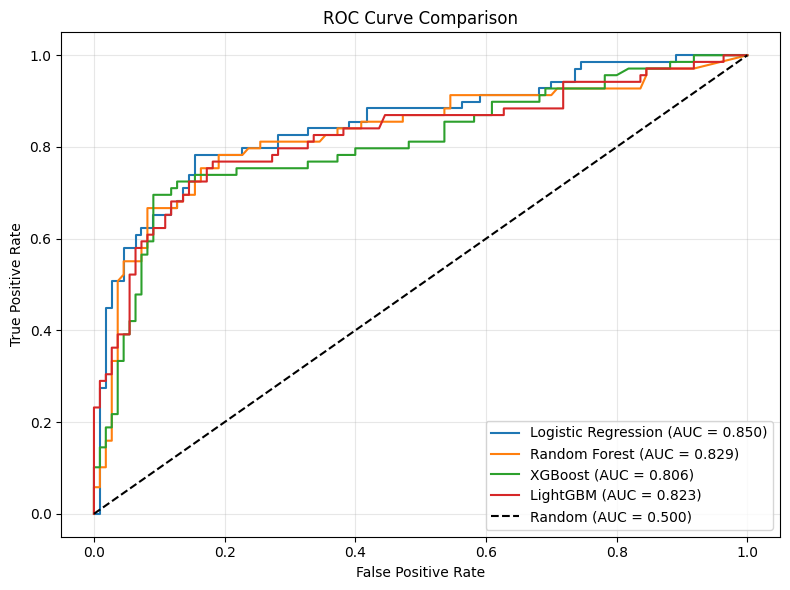

In [46]:
plt.figure(figsize=(8, 6))

for name, (model, prob) in trained_models.items():
    fpr, tpr, _ = roc_curve(y_test_b, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 실험 비교 항목 (과제 필수 요구사항)
Base / Exp-1 / Exp-2 / Exp-3 조합별 성능 비교


In [47]:
experiment_configs = [
    ("Base",  "median",       "label",  "standard", False),
    ("Exp-1", "mean",         "onehot", "standard", False),
    ("Exp-2", "median",       "label",  "minmax",   True),
    ("Exp-3", "most_frequent","onehot", "robust",   True),
]

all_exp_results = []

for exp_name, imp, enc, scale, fs in experiment_configs:
    for model_type, model_label in [("logistic", "Logistic Regression"), ("rf", "Random Forest")]:
        result = run_experiment(
            raw_df,
            impute_strategy=imp,
            encoding=enc,
            scaler_type=scale,
            feature_selection=fs,
            n_features=8,
            model_type=model_type
        )
        all_exp_results.append({
            "Experiment": exp_name,
            "결측치":      imp,
            "인코딩":      enc,
            "스케일링":    scale,
            "Feature Sel": "O" if fs else "X",
            "Model":       model_label,
            "Accuracy":    result["Accuracy"],
            "Precision":   result["Precision"],
            "Recall":      result["Recall"],
            "F1":          result["F1"],
            "ROC_AUC":     result["ROC_AUC"]
        })

exp_all_df = pd.DataFrame(all_exp_results)

for model_label in ["Logistic Regression", "Random Forest"]:
    sub = exp_all_df[exp_all_df["Model"] == model_label].drop(columns="Model").reset_index(drop=True)
    print(f"\n=== {model_label} ===")
    display(sub)



=== Logistic Regression ===


,Experiment,결측치,인코딩,스케일링,Feature Sel,Accuracy,Precision,Recall,F1,ROC_AUC
0,Base,median,label,standard,X,0.8045,0.7833,0.6812,0.7287,0.8491
1,Exp-1,mean,onehot,standard,X,0.7989,0.7895,0.6522,0.7143,0.8457
2,Exp-2,median,label,minmax,O,0.7877,0.7541,0.6667,0.7077,0.8461
3,Exp-3,most_frequent,onehot,robust,O,0.7989,0.7705,0.6812,0.7231,0.8435



=== Random Forest ===


,Experiment,결측치,인코딩,스케일링,Feature Sel,Accuracy,Precision,Recall,F1,ROC_AUC
0,Base,median,label,standard,X,0.8101,0.7692,0.7246,0.7463,0.8209
1,Exp-1,mean,onehot,standard,X,0.7989,0.7463,0.7246,0.7353,0.8231
2,Exp-2,median,label,minmax,O,0.7989,0.7538,0.7101,0.7313,0.8236
3,Exp-3,most_frequent,onehot,robust,O,0.8212,0.7761,0.7536,0.7647,0.8240


— GridSearchCV 하이퍼파라미터 최적화


In [48]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Best 전처리 데이터 (Feature Selection 적용 X: GridSearchCV가 전체 변수로 탐색하도록)
X_tr_p, X_te_p, y_tr_p, y_te_p = get_best_data(raw_df, feature_selection=False)

# Pipeline: 스케일링 + RandomForest
pipe_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(random_state=SEED))
])

param_grid = {
    "classifier__n_estimators":  [100, 200, 300],
    "classifier__max_depth":     [None, 5, 10],
    "classifier__min_samples_split": [2, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid_search = GridSearchCV(
    pipe_rf,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_tr_p, y_tr_p)

print("Best Parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", round(grid_search.best_score_, 4))

best_model = grid_search.best_estimator_
pred_gs = best_model.predict(X_te_p)
prob_gs = best_model.predict_proba(X_te_p)[:, 1]

print("\n=== GridSearchCV 최적 모델 성능 (Test Set) ===")
print(f"Accuracy : {accuracy_score(y_te_p, pred_gs):.4f}")
print(f"F1-Score : {f1_score(y_te_p, pred_gs):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_te_p, prob_gs):.4f}")

# Default Random Forest(튜닝 전)와 비교
default_rf = RandomForestClassifier(n_estimators=300, random_state=SEED)
default_rf.fit(X_tr_p, y_tr_p)
pred_default = default_rf.predict(X_te_p)
prob_default = default_rf.predict_proba(X_te_p)[:, 1]

gs_compare = pd.DataFrame([
    {
        "Model": "Random Forest (Default)",
        "Accuracy": round(accuracy_score(y_te_p, pred_default), 4),
        "F1": round(f1_score(y_te_p, pred_default), 4),
        "ROC_AUC": round(roc_auc_score(y_te_p, prob_default), 4)
    },
    {
        "Model": "Random Forest (GridSearchCV Best)",
        "Accuracy": round(accuracy_score(y_te_p, pred_gs), 4),
        "F1": round(f1_score(y_te_p, pred_gs), 4),
        "ROC_AUC": round(roc_auc_score(y_te_p, prob_gs), 4)
    }
])

print("\n=== 튜닝 전/후 성능 비교 ===")
display(gs_compare)


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters: {'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}
Best CV ROC-AUC: 0.8832

=== GridSearchCV 최적 모델 성능 (Test Set) ===
Accuracy : 0.7765
F1-Score : 0.6721
ROC-AUC  : 0.8420

=== 튜닝 전/후 성능 비교 ===


,Model,Accuracy,F1,ROC_AUC
0,Random Forest (Default),0.8101,0.7463,0.826
1,Random Forest (GridSearchCV Best),0.7765,0.6721,0.842
